## 主成分分析によるデータ圧縮

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split

import numpy as np

import pandas as pd

cols = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

df_wine = pd.read_csv("wine.data",names=cols,header=None)

y, x = df_wine["Class label"], df_wine.iloc[:,1:]
x_train, x_test, y_train, y_test = train_test_split(x.values,y.values, test_size=0.3, random_state=0, stratify=y)

from sklearn.preprocessing import StandardScaler
std = StandardScaler()
x_train_std = std.fit_transform(x_train)
x_test_std = std.transform(x_test)

共分散行列(covariance matrix)
$
Cov = \frac{1}{n}\sum_{i=1}^n
\left(x^{(i)}_j-\mu_j\right)
\left(x^{(i)}_k-\mu_k\right)
$


分散説明率(variance explained ratio)
$\eta_j = \frac{\lambda_j}{\sum_{j=1}^{d}\lambda_j}$


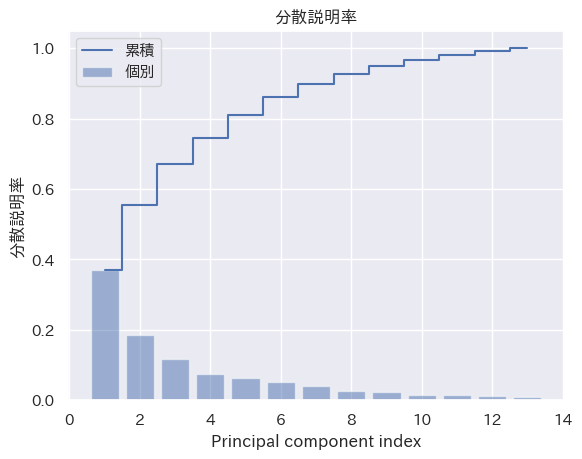

In [28]:
cov_mat = np.cov(x_train_std.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

plt.bar(range(1, 14), var_exp, alpha=0.5, align='center',label='個別')
plt.step(range(1, 14), cum_var_exp, where='mid',label='累積')
plt.title("分散説明率");plt.ylabel('分散説明率');plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.show()

In [15]:
eigen_vecs.shape

(13, 13)

In [39]:
eigen_pairs = [(np.abs(eig), eigen_vecs[:,idx]) for idx, eig in enumerate(eigen_vals)]
eigen_pairs = sorted(eigen_pairs, key=lambda k:k[0], reverse=True)

ev0=eigen_pairs[0][1]
ev1= eigen_pairs[1][1]
w = np.array([ev0,ev1]).T


x_train_std.dot(w).shape

(124, 2)

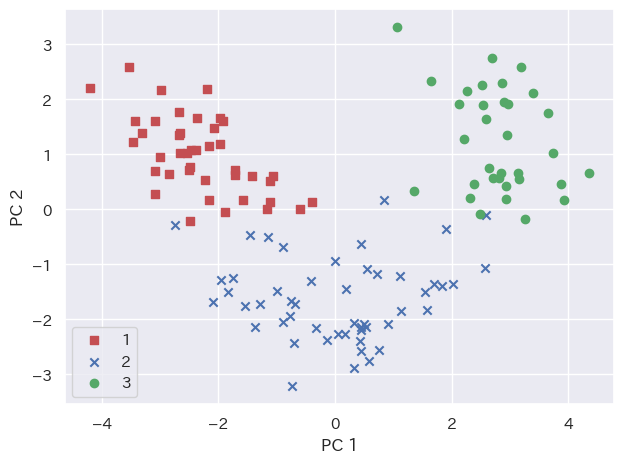

In [40]:
X_train_pca = x_train_std.dot(w)
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']

for l, c, m in zip(np.unique(y_train), colors, markers):
  plt.scatter(
    X_train_pca[y_train == l, 0], 
    X_train_pca[y_train == l, 1], 
    c=c, label=l, marker=m
  )

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
# plt.savefig('images/05_03.png', dpi=300)
plt.show()